<a href="https://colab.research.google.com/github/IbrahimExe/PremierLeague_CNN/blob/main/PLClubs_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Custom Images - Student Assignment



## Assignment Tasks

### Part 1: Dataset Selection
Choose **ONE** of the following datasets (or find your own similar dataset):

#### Recommended Datasets:

1. **CIFAR-10** (Easy)
   - 10 classes of objects
   - 60,000 32x32 color images
   - Link: Built into PyTorch/torchvision
   - Good for: First-time custom dataset work

2. **Fashion-MNIST** (Easy-Medium)
   - 10 classes of clothing items
   - 70,000 28x28 grayscale images
   - Link: Built into PyTorch/torchvision
   - Good for: Understanding grayscale vs color

3. **Food-101** (Medium)
   - 101 food categories
   - 101,000 images
   - Link: https://www.kaggle.com/datasets/dansbecker/food-101
   - Good for: Real-world multi-class problems

4. **Intel Image Classification** (Medium)
   - 6 scene categories (buildings, forest, glacier, mountain, sea, street)
   - ~25,000 150x150 images
   - Link: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
   - Good for: Scene recognition

5. **Rock-Paper-Scissors** (Easy)
   - 3 classes
   - 2,188 images
   - Link: https://www.kaggle.com/datasets/drgfreeman/rockpaperscissors
   - Good for: Simple gesture recognition

**Your Task:**
- Download and prepare your chosen dataset
- Organize it in the folder structure shown in the notebook (separate folders for each class)
- Document your choice and reasoning

---

### Part 2: Model Architecture Adjustments
Modify the CNN architecture from the notebook to suit your dataset. Consider:

#### Required Changes:

1. **Input Size Adjustments**
   - Adjust `transforms.Resize()` and `transforms.CenterCrop()` based on your image dimensions
   - Example: If using 150x150 images instead of 32x32, update accordingly

2. **Output Layer Modification**
   - Change the final `nn.Linear` layer to match your number of classes
   - Example: For 10 classes, final layer should be `nn.Linear(72, 10)`

3. **Architecture Experiments** (try at least 2 variations):
   
   **Variation A: Deeper Network**
   ```python
   # Add one more convolutional block
   nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
   nn.ReLU(inplace=True)
   nn.MaxPool2d(2, 2)
   ```

   **Variation B: Wider Network**
   ```python
   # Increase number of filters
   nn.Conv2d(3, 12, ...)  # instead of 6
   nn.Conv2d(12, 32, ...) # instead of 16
   ```

   **Variation C: Different Kernel Sizes**
   ```python
   # Try 5x5 kernels instead of 3x3
   nn.Conv2d(3, 6, kernel_size=5, ...)
   ```

**Deliverable:** Document each architecture variation you try and calculate the number of parameters for each.

---

### Part 3: Hyperparameter Experimentation

Test **at least 3** different hyperparameter configurations. Track your results in a table.

#### Hyperparameters to Experiment With:

1. **Learning Rate**
   - Try: `0.0001`, `0.001`, `0.01`
   - Effect: Controls how fast the model learns

2. **Batch Size**
   - Try: `32`, `128`, `512`
   - Effect: Affects training stability and speed

3. **Number of Epochs**
   - Try: `5`, `10`, `15`
   - Effect: More epochs = more training time

4. **Optimizer**
   ```python
   # Try different optimizers:
   optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
   optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
   optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
   ```

5. **Data Augmentation**
   ```python
   # Add more augmentation techniques:
   transforms.RandomRotation(15),      # Rotate up to 15 degrees
   transforms.ColorJitter(brightness=0.2, contrast=0.2),
   transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
   ```

#### Results Tracking Template:

| Experiment | Architecture | Learning Rate | Batch Size | Epochs | Optimizer | Train Acc | Val Acc | Notes            |
| ---------- | ------------ | ------------- | ---------- | ------ | --------- | --------- | ------- | ---------------- |
| 1          | Baseline     | 0.001         | 512        | 4      | Adam      | 57%       | 64%     | From notebook    |
| 2          | Deeper       | 0.001         | 512        | 4      | Adam      | ?         | ?       | Added conv layer |
| 3          | ...          | ...           | ...        | ...    | ...       | ?         | ?       | ...              |

---

### Part 4: Analysis and Debugging

#### Required Analysis:

1. **Plot Training Curves**
   - Loss curves (training vs validation)
   - Accuracy curves (training vs validation)
   - Identify: Is your model overfitting or underfitting?

2. **Confusion Matrix Analysis**
   - Generate confusion matrix for your best model
   - Identify which classes are most confused
   - Example questions to answer:
     - Which class has the lowest accuracy?
     - Which two classes are most often confused?
     - Why might this confusion occur?

3. **Error Analysis**
   - Display 10-20 misclassified images
   - Analyze patterns:
     - Are misclassified images blurry?
     - Do they contain unusual angles or lighting?
     - Are some classes inherently similar?

4. **Performance Metrics**
   ```python
   from sklearn.metrics import classification_report
   print(classification_report(all_labels, all_preds,
                               target_names=class_names))
   ```

#### Debugging Checklist:

If your model isn't performing well, check:
- [ ] Are images normalized correctly?
- [ ] Is the learning rate too high/low?
- [ ] Is the model too simple/complex for the task?
- [ ] Is there enough data augmentation?
- [ ] Are you training for enough epochs?
- [ ] Is there class imbalance in your dataset?



## Example Hyperparameter Combinations to Try

### Configuration 1: Conservative
```python
learning_rate = 0.001
batch_size = 128
epochs = 10
optimizer = Adam
augmentation = Basic (rotation + flip)
```

### Configuration 2: Aggressive
```python
learning_rate = 0.01
batch_size = 512
epochs = 5
optimizer = SGD with momentum
augmentation = Heavy (rotation + flip + color jitter)
```

### Configuration 3: Careful
```python
learning_rate = 0.0001
batch_size = 32
epochs = 15
optimizer = Adam
augmentation = Moderate (rotation + flip + affine)
```




In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder

from torchvision.utils import make_grid
from torch.utils.data import DataLoader, Subset
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

!pip install opendatasets

# Importing Dataset & Creating Transforms

In [ ]:
# Kaggle Username + API Key

import opendatasets as od
od.download("https://www.kaggle.com/datasets/alexteboul/english-premier-league-logo-detection-20k-images/data", data_dir="data")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ibrahimiexe
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/alexteboul/english-premier-league-logo-detection-20k-images


100%|██████████| 521M/521M [00:10<00:00, 52.8MB/s]

In [ ]:
size = 128

train_transform = transforms.Compose([
        transforms.RandomRotation(10),      # rotate +/- 10 degrees
        transforms.RandomHorizontalFlip(),  # reverse 50% of images
        transforms.ColorJitter(brightness=0.2, contrast=0.2), # Creating different color variations
        transforms.Resize(size),
        #transforms.CenterCrop(size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

test_transform = transforms.Compose([
        transforms.Resize(size),
        #transforms.CenterCrop(size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

In [ ]:
root = Path("/content/data/english-premier-league-logo-detection-20k-images/epl-logos-big/epl-logos-big")

# 1) Load everything without transforms
base = datasets.ImageFolder(root=str(root), transform=None) # base.classes

In [ ]:
root = Path("/content/data/english-premier-league-logo-detection-20k-images/epl-logos-big/epl-logos-big")

# 1) Load everything without transforms
base = datasets.ImageFolder(root=str(root), transform=None) # base.classes

print(f"Total number of images in the dataset: {len(base)}")

print("\nTeam Names (Classes):")
for class_name in base.classes:
    print(f"  - {class_name}")

print("\nWhere each team has 1000 images representing their crest/ logo.")

if len(base) > 0:
    first_image, _ = base[19999]
    # PIL Image objects have .size attribute as (width, height)
    print(f"\nImage dimensions (width, height): {first_image.size}")
else:
    print("\nNo images found in the dataset to determine dimensions.")

Total number of images in the dataset: 20000

Team Names (Classes):
  - arsenal
  - aston-villa
  - brentford
  - brighton
  - burnley
  - chelsea
  - crystal-palace
  - everton
  - leeds
  - leicester-city
  - liverpool
  - manchester-city
  - manchester-united
  - newcastle
  - norwich
  - southampton
  - tottenham
  - watford
  - west-ham
  - wolves

Where each team has 1000 images representing their crest/ logo.

Image dimensions (width, height): (140, 140)


In [ ]:
# 2) Shuffle & split indices (80/20)
n = len(base)
perm = torch.randperm(n)
n_train = int(0.8 * n)
idx_train = perm[:n_train]
idx_test  = perm[n_train:]

# Create separate datasets with different transforms
train_base = ImageFolder(root=str(root), transform=train_transform)
test_base = ImageFolder(root=str(root), transform=test_transform)

train_dataset = Subset(train_base, idx_train)
test_dataset = Subset(test_base, idx_test)

# 4) DataLoaders
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True) # False <-> check next
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

train_loader_2 = DataLoader(train_base, batch_size=1536, shuffle=True) # False <-> check next
test_loader_2  = DataLoader(test_base,  batch_size=384, shuffle=False)

Text(0.5, 1.0, 'manchester-united')

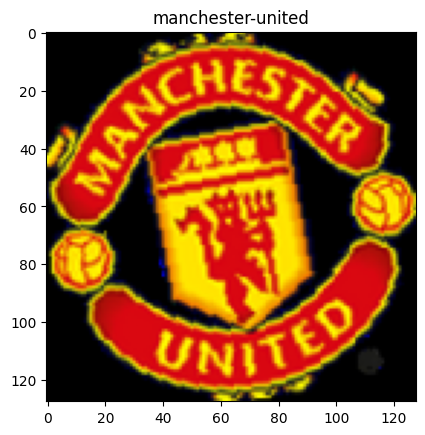

In [ ]:
for images, labels in train_loader:
    break

img = images[0]
l = labels[0]

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
im_inv = inv_normalize(img)

plt.imshow(im_inv.squeeze(0).numpy().transpose(1, 2, 0))
plt.title(base.classes[l])

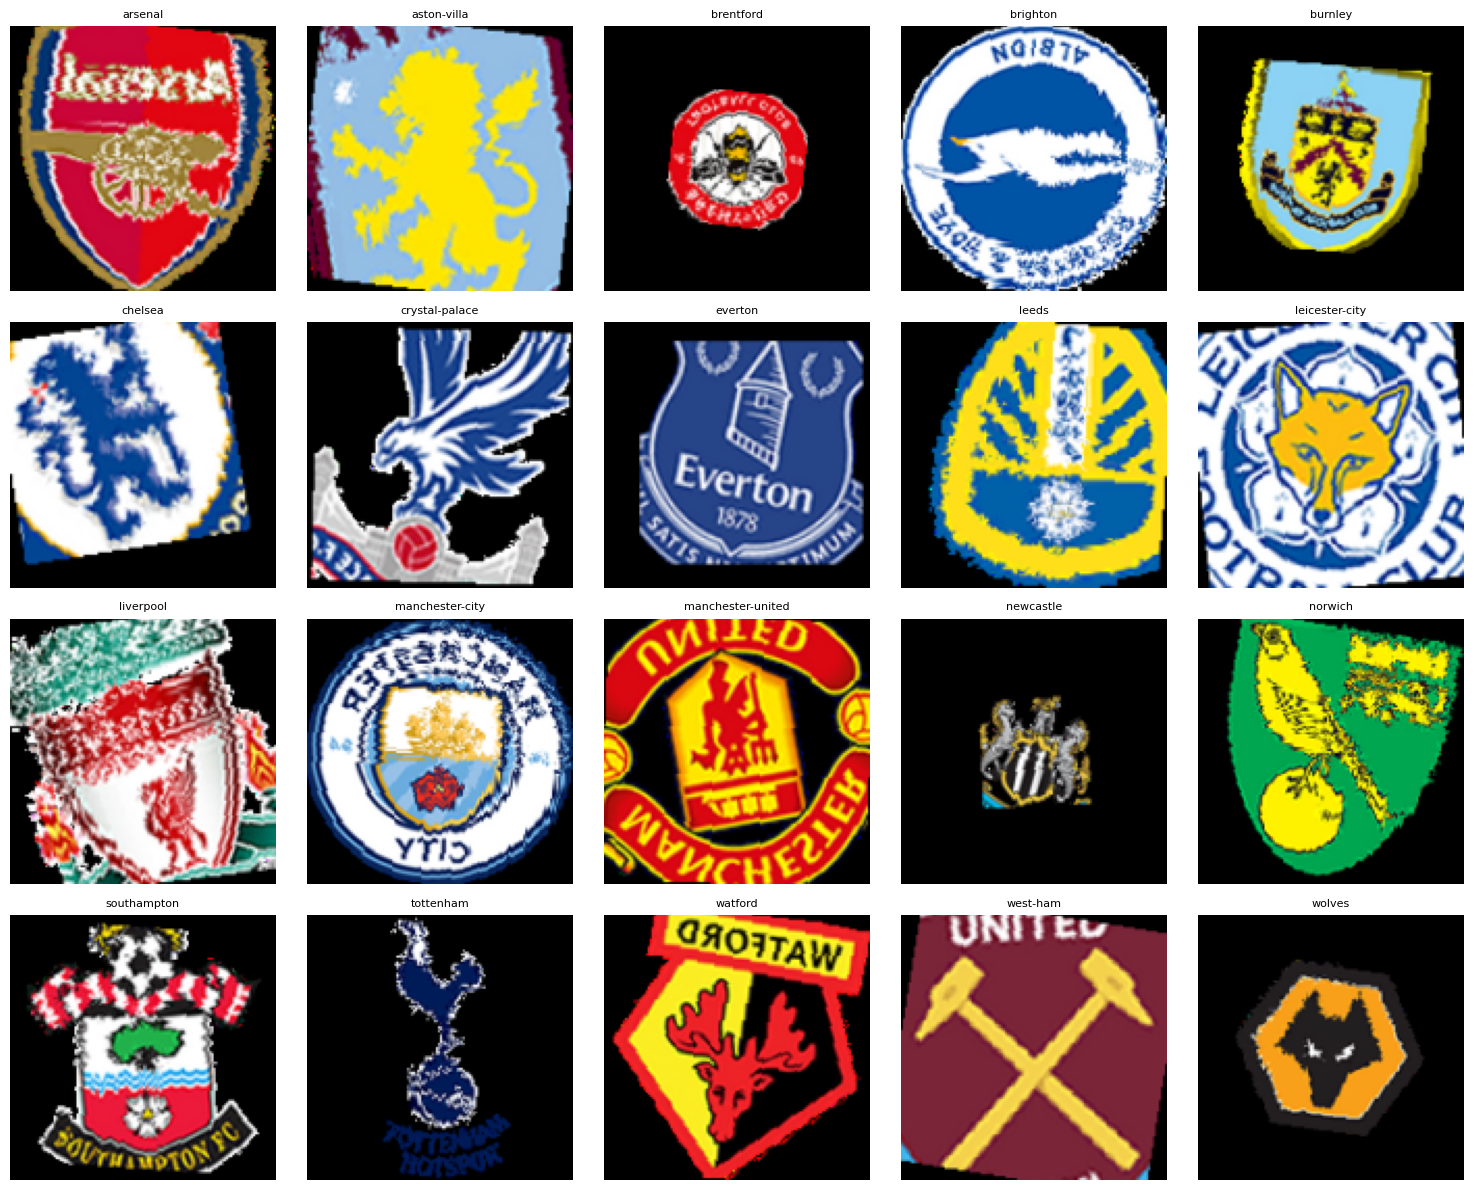

In [ ]:
# Assuming base.classes contains the unique class names
num_classes = len(base.classes)
rows = 4
cols = 5 # For a 4x5 grid, this gives 20 images. Adjust if num_classes is different.

# Collect one image for each unique class
collected_images = {} # {class_idx: (image_tensor, label_idx)}

for i in range(len(train_base)):
    img_tensor, label_idx = train_base[i] # train_base returns image, label with transform
    if label_idx not in collected_images:
        collected_images[label_idx] = (img_tensor, label_idx)
    if len(collected_images) == num_classes:
        break

# Sort collected_images by label_idx to ensure consistent display order
sorted_images = [collected_images[k] for k in sorted(collected_images.keys())]

# Now plot them in a grid
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i in range(num_classes):
    image, label = sorted_images[i]
    image_np = inv_normalize(image).squeeze(0).numpy().transpose(1, 2, 0)
    axes[i].imshow(image_np)
    axes[i].set_title(base.classes[label], fontsize=8) # Smaller font for titles
    axes[i].axis('off')

# Hide any unused subplots if num_classes < rows * cols
for j in range(num_classes, rows * cols):
    if j < len(axes): # Ensure index is valid
        axes[j].axis('off')

plt.tight_layout() # Adjust layout to prevent titles overlapping
plt.show()

# Creating the Convolutional Neural Networks

## Variation A: Deeper Network

In [ ]:
# Deeper Network

class DeepCNN(nn.Module):
  def __init__(self):
    super().__init__()
    # Org: (~ , 3 RGB, Varied h, Varied w) -> Input: (Batches (512), 3 RGB, 128 h, 128 w) from transforms.Resize(size)
    self.features = nn.Sequential(
        # 1st Conv
        nn.Conv2d(3, 6, kernel_size=3, stride=1, padding=0), # 128 - 2 = 126
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2), # 126 / 2 = 63

        # 2nd Conv Block
        nn.Conv2d(6, 16, kernel_size=3, stride=1, padding=0), # 63 - 2 = 61
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2), # 61 / 2 = 30

        # 3rd Conv Block
        nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0), # 30 - 2 = 28
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2), # 28 / 2 = 14
    )

    # Input image size: 128x128
    # After 1st Conv+Pool: (128-3+1)/2 = 63x63 feature maps, 6 channels
    # After 2nd Conv+Pool: (63-3+1)/2 = 30x30 feature maps, 16 channels (using floor division)
    # After 3rd Conv+Pool: (30-3+1)/2 = 14x14 feature maps, 32 channels
    fc_input_features = 32 * 14 * 14 # 6272

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(fc_input_features, 1000),
        nn.ReLU(inplace=True),
        nn.Linear(1000, 500),
        nn.ReLU(inplace=True),
        nn.Linear(500, 140),
        nn.ReLU(inplace=True),
        nn.Linear(140, 20) # Output layer = 20 classes = 20 Teams
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

## Variation B: Wider Network

In [ ]:
# Wider Network

class WideCNN(nn.Module):
  def __init__(self):
    super().__init__()
    # Org: (~ , 3 RGB, Varied h, Varied w) -> Input: (Batches (512), 3 RGB, 128 h, 128 w) from transforms.Resize(size)
    self.features = nn.Sequential(
        # 1st Conv - Wider: increased output channels from 6 to 12
        nn.Conv2d(3, 12, kernel_size=3, stride=1, padding=0), # 128 - 2 = 126
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2), # 126 / 2 = 63

        # 2nd Conv Block - Wider: increased output channels from 16 to 32
        nn.Conv2d(12, 32, kernel_size=3, stride=1, padding=0), # 63 - 2 = 61
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2), # 61 / 2 = 30

        # 3rd Conv Block - Wider: increased output channels from 32 to 64
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0), # 30 - 2 = 28
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2), # 28 / 2 = 14
    )

    # After 3rd Conv+Pool: 14x14 feature maps, 64 channels
    fc_input_features = 64 * 14 * 14 # 12544

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(fc_input_features, 1000),
        nn.ReLU(inplace=True),
        nn.Linear(1000, 200),
        nn.ReLU(inplace=True),
        nn.Linear(200, 20) # Output layer = 20 classes = 20 Teams
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

## Variation C: Different Kernel Sizes

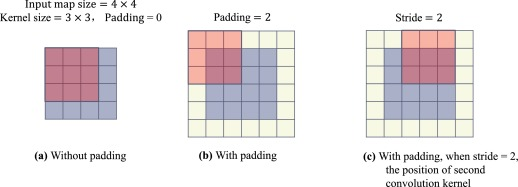

In [ ]:
# Different Kernel Sizes

class KernelCNN(nn.Module):
  def __init__(self):
    super().__init__()
    # Org: (~ , 3 RGB, Varied h, Varied w) -> Input: (Batches (512), 3 RGB, 128 h, 128 w) from transforms.Resize(size)
    self.features = nn.Sequential(
        # 1st Conv with 5x5 kernel
        nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=0), # 128 - 5 + 1 = 124
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2), # 124 / 2 = 62

        # 2nd Conv Block with 5x5 kernel
        nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0), # 62 - 5 + 1 = 58
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2), # 58 / 2 = 29

        # 3rd Conv Block with 5x5 kernel
        nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=0), # 29 - 5 + 1 = 25
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2), # 25 / 2 = 12 (using floor division)
    )

    # After 3rd Conv+Pool: 12x12 feature maps, 32 channels
    fc_input_features = 32 * 12 * 12 # 4608

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(fc_input_features, 1000),
        nn.ReLU(inplace=True),
        nn.Linear(1000, 200),
        nn.ReLU(inplace=True),
        nn.Linear(200, 20) # Output layer = 20 classes = 20 Teams
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

## Instansiating the Models

In [ ]:
torch.manual_seed(42)

deepNetwork = DeepCNN()
wideNetwork = WideCNN()
kernelNetwork = KernelCNN()

# Training the Models

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(deepNetwork.parameters(), lr=0.001)
optimizer_2 = torch.optim.SGD(wideNetwork.parameters(), lr=0.001, momentum=0.9)
optimizer_3 = torch.optim.Adam(kernelNetwork.parameters(), lr=0.01) # Increased learning rate from 0.0001 to 0.01

param_count = sum(p.numel() for p in deepNetwork.parameters() if p.requires_grad)
print(f"The Deep Model has {param_count} trainable parameters.")
print("Deep Model Training with an Adam Optimizer learning rate of 0.001")

param_count = sum(p.numel() for p in wideNetwork.parameters() if p.requires_grad)
print(f"\nThe Wide Model has {param_count} trainable parameters.")
print("Wide Model Training with a Stochastic Gradient Descent Optimizer learning rate of 0.001 & Momentum of 0.9")

param_count = sum(p.numel() for p in kernelNetwork.parameters() if p.requires_grad)
print(f"\nKernel Model has {param_count} trainable parameters.")
print("Kernel Model Training with an Adam Optimizer learning rate of 0.01")

The Deep Model has 6852148 trainable parameters.
Deep Model Training with an Adam Optimizer learning rate of 0.001

The Wide Model has 12771540 trainable parameters.
Wide Model Training with a Stochastic Gradient Descent Optimizer learning rate of 0.001 & Momentum of 0.9

Kernel Model has 4828924 trainable parameters.
Kernel Model Training with an Adam Optimizer learning rate of 0.01


In [ ]:
# --- helpers ---
def train(model, loader, criterion, optimizer, epoch):
    model.train()
    total_loss, total_correct = 0.0, 0
    for i, batch in enumerate(loader, start=1):
        images, labels = batch
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()



    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / len(loader.dataset)
    return avg_loss, accuracy

def evaluate(model, loader, criterion, epoch):
    model.eval()
    total_loss, total_correct = 0.0, 0
    with torch.no_grad():
        for i, batch in enumerate(loader, start=1):
            images, labels = batch
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = total_correct / len(loader.dataset)
    return avg_loss, accuracy

## Training the Deep Model

In [ ]:
# Deep Network Training:
epochs = 10

train_losses, train_accuracies = [], []
test_losses,  test_accuracies  = [], []

criterion = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(deepNetwork.parameters(), lr=0.001)

print("Starting training for Deep Network:")
for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train(deepNetwork, train_loader, criterion, optimizer_1, epoch)
    te_loss, te_acc = evaluate(deepNetwork, test_loader,  criterion, epoch)

    train_losses.append(tr_loss)
    train_accuracies.append(tr_acc)
    test_losses.append(te_loss)
    test_accuracies.append(te_acc)

    print(f"Epoch {epoch:02d} | "
          f"Train: loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
          f"Test:  loss={te_loss:.4f}, acc={te_acc:.4f}")

Starting training for Deep Network:
Epoch 01 | Train: loss=1.4832, acc=0.5319 | Test:  loss=0.3998, acc=0.8700
Epoch 02 | Train: loss=0.2403, acc=0.9223 | Test:  loss=0.0591, acc=0.9872
Epoch 03 | Train: loss=0.0650, acc=0.9832 | Test:  loss=0.0243, acc=0.9955
Epoch 04 | Train: loss=0.0367, acc=0.9908 | Test:  loss=0.0153, acc=0.9968
Epoch 05 | Train: loss=0.0275, acc=0.9929 | Test:  loss=0.0129, acc=0.9968
Epoch 06 | Train: loss=0.0402, acc=0.9876 | Test:  loss=0.0163, acc=0.9940
Epoch 07 | Train: loss=0.0268, acc=0.9923 | Test:  loss=0.0082, acc=0.9985
Epoch 08 | Train: loss=0.0093, acc=0.9977 | Test:  loss=0.0037, acc=0.9992
Epoch 09 | Train: loss=0.0041, acc=0.9991 | Test:  loss=0.0031, acc=0.9992
Epoch 10 | Train: loss=0.0056, acc=0.9986 | Test:  loss=0.0051, acc=0.9985


The Deep Network took ~29 mins to train for 10 Epochs.

## Training the Wider Network Model

In [ ]:
# Wide Netwrok Training
epochs = 10

train_losses_w, train_accuracies_w = [], []
test_losses_w,  test_accuracies_w  = [], []

criterion = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.SGD(wideNetwork.parameters(),
                              lr=0.001, momentum=0.9)

print("Starting training for Wide Network:")
for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train(wideNetwork, train_loader_2, criterion, optimizer_2, epoch)
    te_loss, te_acc = evaluate(wideNetwork, test_loader_2,  criterion, epoch)

    train_losses_w.append(tr_loss)
    train_accuracies_w.append(tr_acc)
    test_losses_w.append(te_loss)
    test_accuracies_w.append(te_acc)

    print(f"Epoch {epoch:02d} | "
          f"Train: loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
          f"Test:  loss={te_loss:.4f}, acc={te_acc:.4f}")

Starting training for Wide Network:
Epoch 01 | Train: loss=2.9956, acc=0.0500 | Test:  loss=2.9930, acc=0.0519
Epoch 02 | Train: loss=2.9910, acc=0.0540 | Test:  loss=2.9873, acc=0.0535
Epoch 03 | Train: loss=2.9856, acc=0.0561 | Test:  loss=2.9812, acc=0.0563
Epoch 04 | Train: loss=2.9798, acc=0.0553 | Test:  loss=2.9744, acc=0.0571
Epoch 05 | Train: loss=2.9731, acc=0.0717 | Test:  loss=2.9664, acc=0.1025
Epoch 06 | Train: loss=2.9649, acc=0.1138 | Test:  loss=2.9562, acc=0.1326
Epoch 07 | Train: loss=2.9545, acc=0.1262 | Test:  loss=2.9431, acc=0.1338
Epoch 08 | Train: loss=2.9409, acc=0.1477 | Test:  loss=2.9259, acc=0.1685
Epoch 09 | Train: loss=2.9226, acc=0.1773 | Test:  loss=2.9016, acc=0.1764
Epoch 10 | Train: loss=2.8960, acc=0.1769 | Test:  loss=2.8663, acc=0.1817


The Wide Model took around ~1 hr 25 mins to train for 10 Epochs.

## Training Larger Kernel Model

In [ ]:
# Kernel Network Training
epochs = 10

train_losses_k, train_accuracies_k = [], []
test_losses_k,  test_accuracies_k  = [], []

criterion = nn.CrossEntropyLoss()
optimizer_3 = torch.optim.Adam(kernelNetwork.parameters(), lr=0.01) # Increased learning rate from 0.0001 to 0.01

print("Starting training for Kernel Model:")
for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train(kernelNetwork, train_loader, criterion, optimizer_3, epoch)
    te_loss, te_acc = evaluate(kernelNetwork, test_loader,  criterion, epoch)

    train_losses_k.append(tr_loss)
    train_accuracies_k.append(tr_acc)
    test_losses_k.append(te_loss)
    test_accuracies_k.append(te_acc)

    print(f"Epoch {epoch:02d} | "
          f"Train: loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
          f"Test:  loss={te_loss:.4f}, acc={te_acc:.4f}")

Starting training for Kernel Model:
Epoch 01 | Train: loss=4.3830, acc=0.0483 | Test:  loss=2.9964, acc=0.0480
Epoch 02 | Train: loss=2.9964, acc=0.0470 | Test:  loss=2.9963, acc=0.0485
Epoch 03 | Train: loss=2.9965, acc=0.0493 | Test:  loss=2.9963, acc=0.0483
Epoch 04 | Train: loss=2.9968, acc=0.0471 | Test:  loss=2.9967, acc=0.0485
Epoch 05 | Train: loss=2.9961, acc=0.0488 | Test:  loss=2.9965, acc=0.0483
Epoch 06 | Train: loss=2.9961, acc=0.0506 | Test:  loss=2.9964, acc=0.0450
Epoch 07 | Train: loss=2.9961, acc=0.0464 | Test:  loss=2.9963, acc=0.0483
Epoch 08 | Train: loss=2.9961, acc=0.0455 | Test:  loss=2.9964, acc=0.0483
Epoch 09 | Train: loss=2.9962, acc=0.0488 | Test:  loss=2.9965, acc=0.0450
Epoch 10 | Train: loss=2.9962, acc=0.0499 | Test:  loss=2.9966, acc=0.0447


The Kernel Model took ~32 mins to train for 10 Epochs.

# Plotting Graphs for the 3 Models

## Loss & Accuracy Line Graphs:

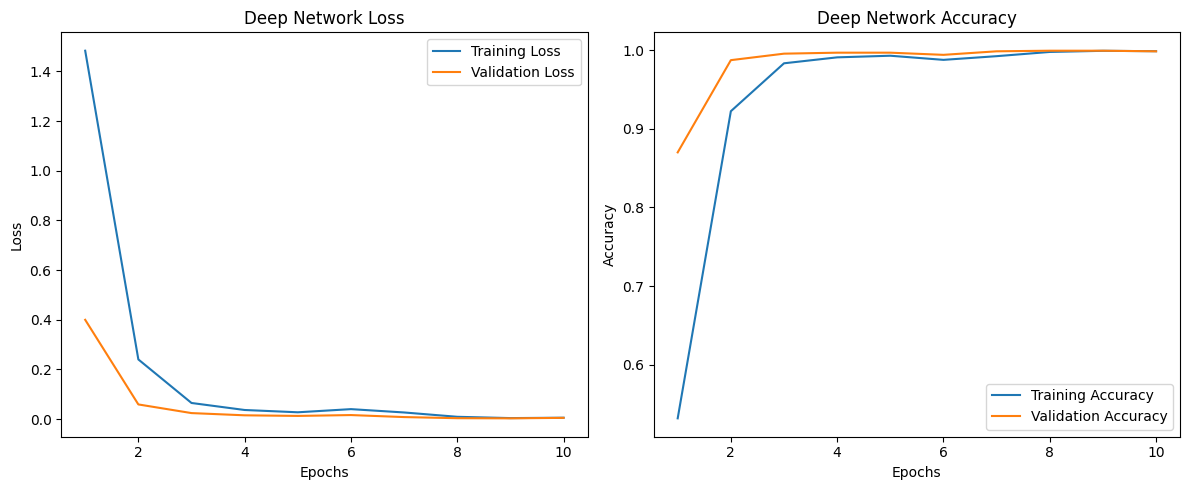

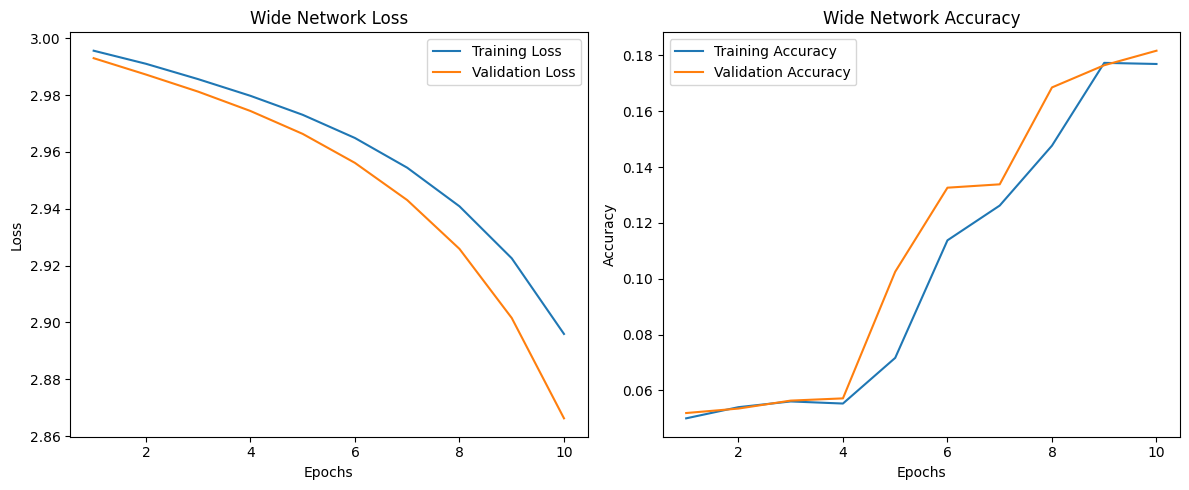

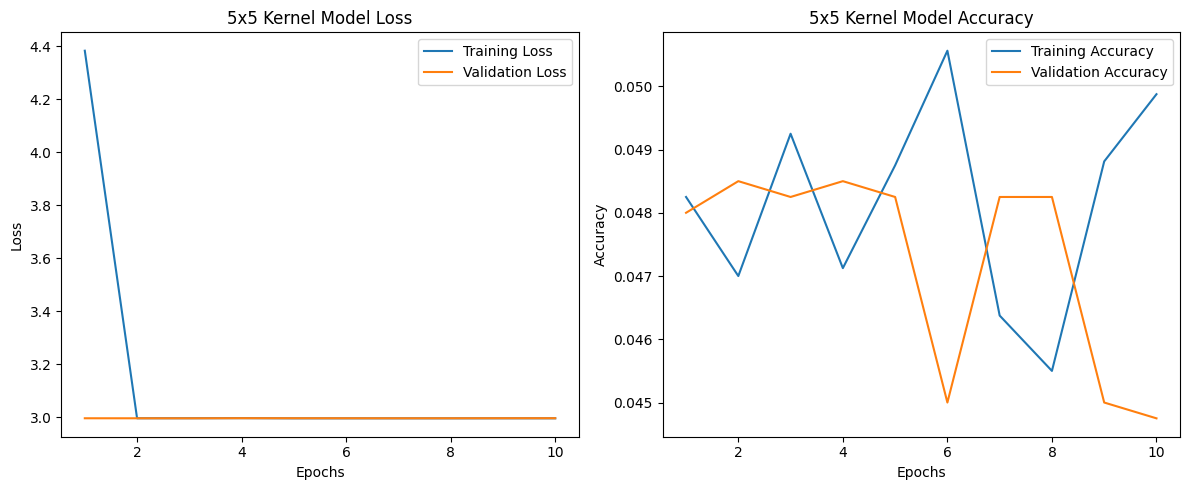

In [ ]:
import matplotlib.pyplot as plt

# Plotting for Deep Network
epochs_model1 = range(1, len(train_losses) + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_model1, train_losses, label='Training Loss')
plt.plot(epochs_model1, test_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Deep Network Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_model1, train_accuracies, label='Training Accuracy')
plt.plot(epochs_model1, test_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Deep Network Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Plotting for Wide Network
epochs_model2 = range(1, len(train_losses_w) + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_model2, train_losses_w, label='Training Loss')
plt.plot(epochs_model2, test_losses_w, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Wide Network Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_model2, train_accuracies_w, label='Training Accuracy')
plt.plot(epochs_model2, test_accuracies_w, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Wide Network Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Plotting for Kernel Network
epochs_model3 = range(1, len(train_losses_k) + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_model3, train_losses_k, label='Training Loss')
plt.plot(epochs_model3, test_losses_k, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('5x5 Kernel Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_model3, train_accuracies_k, label='Training Accuracy')
plt.plot(epochs_model3, test_accuracies_k, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('5x5 Kernel Model Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Confusion Matrix of the Best Model

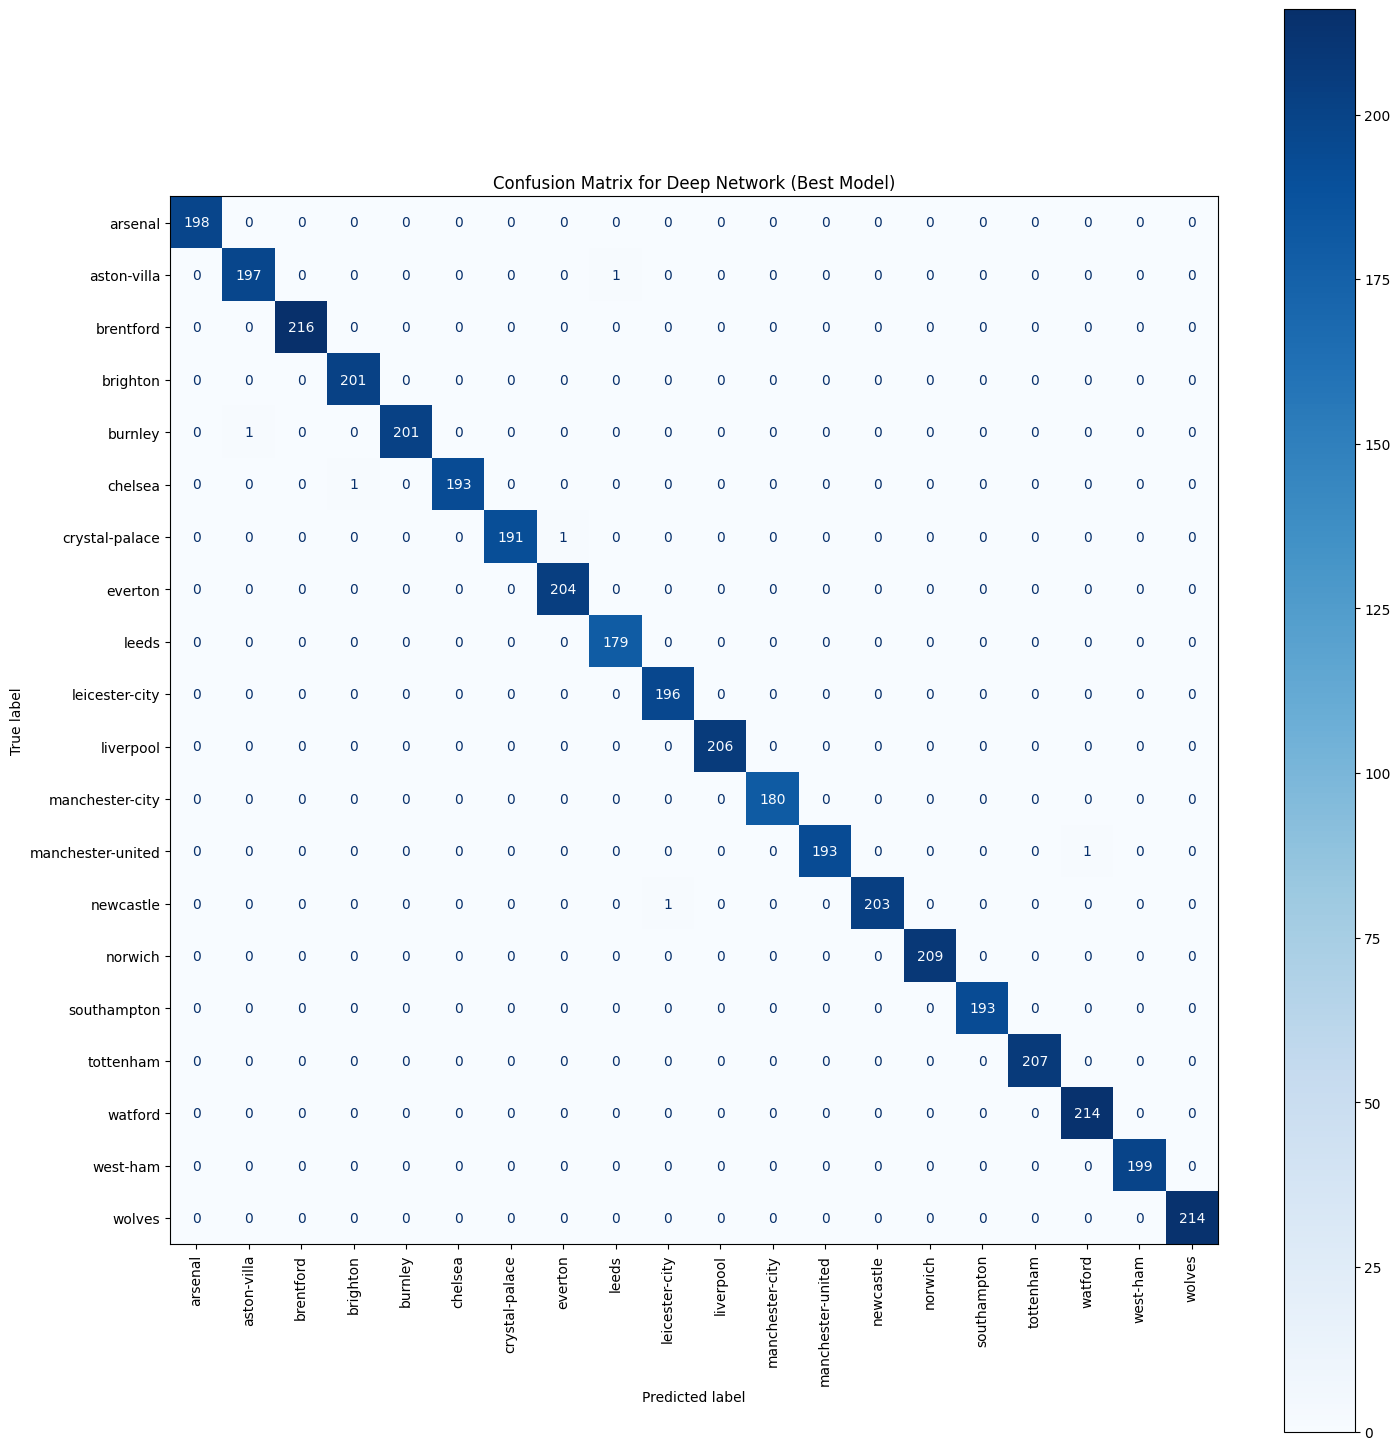

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# The first model, the deep network model, performed the best.

all_preds = []
all_labels = []

deepNetwork.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = deepNetwork(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Get class names
class_names = base.classes

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix interactively
# We use a static plot here, but with labels it becomes 'interactive' in terms of inspection
fig, ax = plt.subplots(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix for Deep Network (Best Model)')
plt.tight_layout()
plt.show()

# Misclassified Clubs Examples

In [ ]:
misclassified_indices = np.where(all_preds != all_labels)[0]
num_misclassified = len(misclassified_indices)

print(f"Total number of misclassified images: {num_misclassified}")

Total number of misclassified images: 6


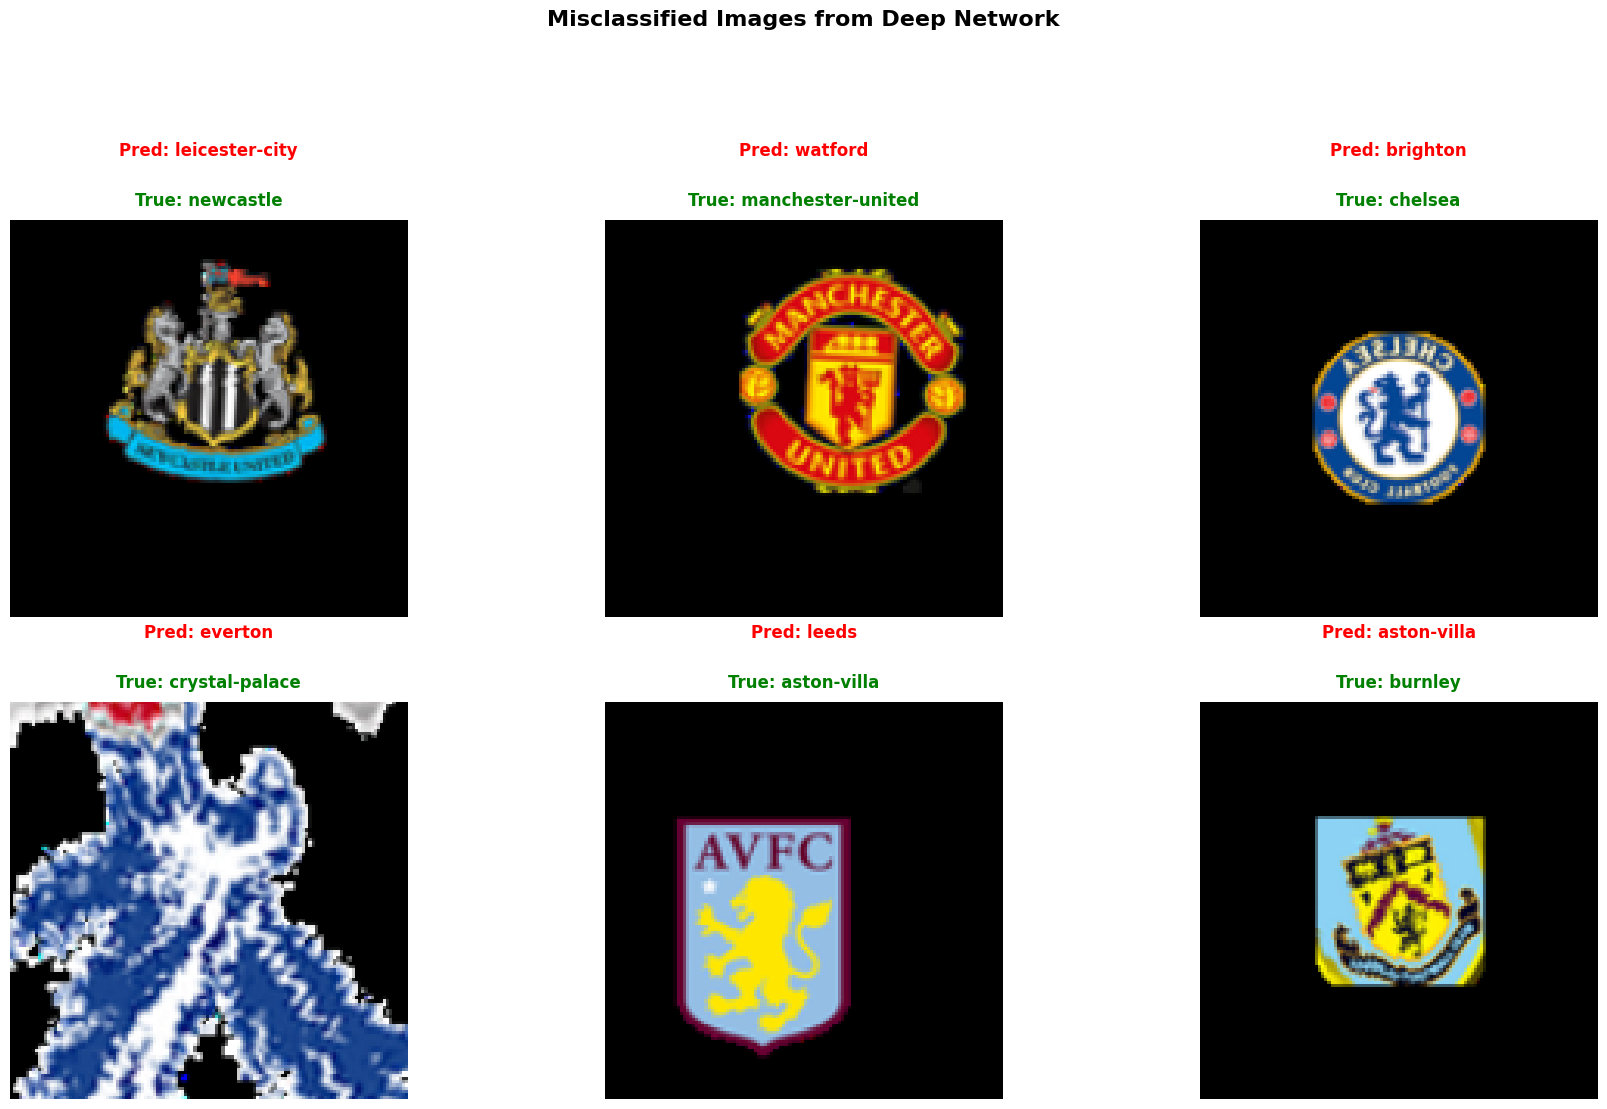

In [ ]:
num_to_display = len(misclassified_indices)

rows_plot = 2 if num_to_display > 3 else 1
cols_plot = (num_to_display + rows_plot - 1) // rows_plot

fig, axes = plt.subplots(rows_plot, cols_plot, figsize=(cols_plot * 6, rows_plot * 6))

if rows_plot > 1 or cols_plot > 1:
    axes = axes.flatten()
else:
    axes = [axes]

for i, idx in enumerate(misclassified_indices[:num_to_display]):
    image_tensor, true_label_idx = test_dataset[idx]
    image_np = inv_normalize(image_tensor).squeeze(0).numpy().transpose(1, 2, 0)
    predicted_label_idx = all_preds[idx]

    true_class_name = class_names[true_label_idx]
    predicted_class_name = class_names[predicted_label_idx]

    axes[i].set_title('')

    axes[i].text(0.5, 1.15, f"Pred: {predicted_class_name}",
                 horizontalalignment='center',
                 verticalalignment='bottom',
                 transform=axes[i].transAxes,
                 color='red', fontsize=12, fontweight='bold')

    axes[i].text(0.5, 1.07, f"True: {true_class_name}",
                 horizontalalignment='center',
                 verticalalignment='top',
                 transform=axes[i].transAxes,
                 color='green', fontsize=12, fontweight='bold')

    # Display the Clubs logo
    axes[i].imshow(image_np)
    axes[i].axis('off')

for j in range(num_to_display, rows_plot * cols_plot):
    if j < len(axes):
        axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.85])
plt.suptitle("Misclassified Images from Deep Network", y=0.95, fontsize=16, fontweight='bold')
plt.show()